In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import train_test_split_edges, negative_sampling
from torch_geometric.transforms import NormalizeFeatures
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Koristimo:", device)

dataset = Planetoid(root='./data', name='Cora', transform=NormalizeFeatures())
data = dataset[0]
data = train_test_split_edges(data)
data = data.to(device)

all_pos_edge_index = torch.cat(
    [data.train_pos_edge_index, data.val_pos_edge_index, data.test_pos_edge_index],
    dim=1,
)

Koristimo: cpu


/tmp/ipykernel_17886/741265350.py:20: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  data = train_test_split_edges(data)


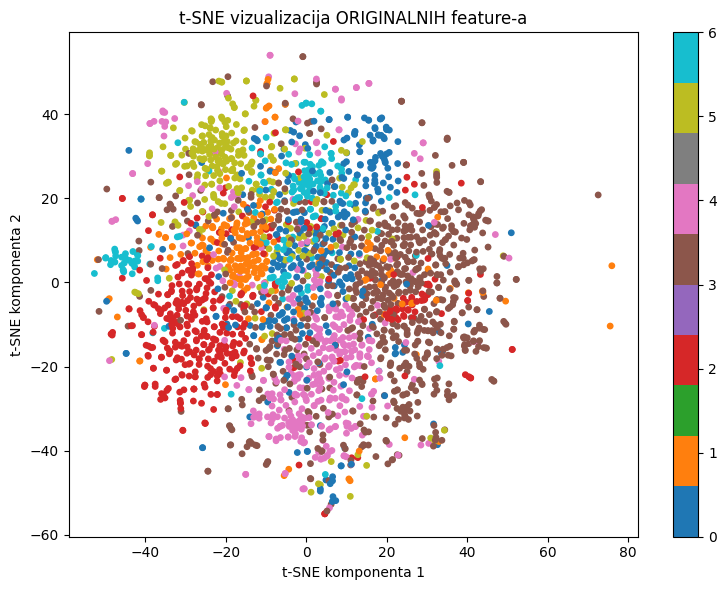

In [2]:

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

x_2d = tsne.fit_transform(data.x.cpu().numpy())

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    x_2d[:, 0],
    x_2d[:, 1],
    c=data.y.cpu().numpy(),
    cmap='tab10',
    s=15
)

plt.colorbar(scatter)
plt.title("t-SNE vizualizacija ORIGINALNIH feature-a")
plt.xlabel("t-SNE komponenta 1")
plt.ylabel("t-SNE komponenta 2")

plt.tight_layout()
plt.savefig('../results/vgae_tSne_feature.png', dpi=150)
plt.show()

In [3]:
from torch_geometric.nn import GCNConv

class VGAE(nn.Module):
    def __init__(self, in_channels, hid_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hid_channels)
        
        self.conv_mu      = GCNConv(hid_channels, out_channels)
        self.conv_logstd  = GCNConv(hid_channels, out_channels)

    def encode(self, x, edge_index):
        h = self.conv1(x, edge_index).relu()
        
        self.mu     = self.conv_mu(h, edge_index)
        self.logstd = self.conv_logstd(h, edge_index)
        self.logstd = self.logstd.clamp(max=10)
        
        if self.training:
            epsilon = torch.randn_like(self.mu)
            z = self.mu + epsilon * self.logstd.exp()
        else:
            z = self.mu
        
        return z
        
    def kl_loss(self):
        return -0.5 * torch.mean(
            1 + 2 * self.logstd - self.mu.pow(2) - (2 * self.logstd).exp()
        )

    def decode(self, z, edge_label_index):
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

    def decode_all(self, z):
        prob_adj = z @ z.t()
        prob_adj = prob_adj.sigmoid()
        return (prob_adj > 0.97).nonzero(as_tuple=False).t()

In [4]:
input_channels  = dataset.num_features
hidden_channels = 64
output_channels = 32

model     = VGAE(in_channels=input_channels, hid_channels=hidden_channels, out_channels=output_channels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

In [5]:
def train():
    model.train()
    optimizer.zero_grad()
    
    z = model.encode(data.x, data.train_pos_edge_index)
    
    neg_edge_index = negative_sampling(
        edge_index=all_pos_edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=data.train_pos_edge_index.shape[1]
    )
    
    edge_index = torch.cat([data.train_pos_edge_index, neg_edge_index], dim=1)
    
    labels = torch.cat([
        torch.ones(data.train_pos_edge_index.shape[1]),
        torch.zeros(neg_edge_index.shape[1])
    ]).to(device)
    
    out  = model.decode(z, edge_index)
    
    bce_loss = criterion(out, labels)
    kl_loss  = model.kl_loss()
    loss     = bce_loss + (1.0 / data.num_nodes) * kl_loss
    
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [6]:
@torch.no_grad()
def evaluate(pos_edge_index, neg_edge_index):
    model.eval()
    z = model.encode(data.x, data.train_pos_edge_index)
    
    edge_index = torch.cat([pos_edge_index, neg_edge_index], dim=1)
    out        = model.decode(z, edge_index).sigmoid().cpu().numpy()
    
    labels = torch.cat([
        torch.ones(pos_edge_index.shape[1]),
        torch.zeros(neg_edge_index.shape[1])
    ]).numpy()
    
    auc = roc_auc_score(labels, out)
    ap  = average_precision_score(labels, out)
    return auc, ap

val_neg  = negative_sampling(all_pos_edge_index, data.num_nodes, data.val_pos_edge_index.shape[1])
test_neg = negative_sampling(all_pos_edge_index, data.num_nodes, data.test_pos_edge_index.shape[1])

train_losses = []
val_aucs     = []
val_aps      = []

best_val_auc = 0
for epoch in range(1, 301):
    loss = train()

    train_losses.append(loss)
    
    if epoch % 10 == 0:
        val_auc, val_ap = evaluate(data.val_pos_edge_index, val_neg)
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}")

        val_aucs.append(val_auc)
        val_aps.append(val_ap)
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), 'best_vgae_model.pt')

model.load_state_dict(torch.load('best_vgae_model.pt'))
test_auc, test_ap = evaluate(data.test_pos_edge_index, test_neg)
print(f"\n=== FINALNI REZULTATI (VGAE) ===")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test AP:  {test_ap:.4f}")

Epoch 010 | Loss: 1.0201 | Val AUC: 0.6967 | Val AP: 0.7157
Epoch 020 | Loss: 0.6866 | Val AUC: 0.6990 | Val AP: 0.7172
Epoch 030 | Loss: 0.6707 | Val AUC: 0.6972 | Val AP: 0.7143
Epoch 040 | Loss: 0.6635 | Val AUC: 0.7086 | Val AP: 0.7238
Epoch 050 | Loss: 0.6476 | Val AUC: 0.7542 | Val AP: 0.7626
Epoch 060 | Loss: 0.5868 | Val AUC: 0.7746 | Val AP: 0.7746
Epoch 070 | Loss: 0.5611 | Val AUC: 0.7807 | Val AP: 0.7651
Epoch 080 | Loss: 0.5292 | Val AUC: 0.8190 | Val AP: 0.8278
Epoch 090 | Loss: 0.5187 | Val AUC: 0.8198 | Val AP: 0.8236
Epoch 100 | Loss: 0.5049 | Val AUC: 0.8236 | Val AP: 0.8228
Epoch 110 | Loss: 0.5006 | Val AUC: 0.8336 | Val AP: 0.8298
Epoch 120 | Loss: 0.4931 | Val AUC: 0.8372 | Val AP: 0.8319
Epoch 130 | Loss: 0.4851 | Val AUC: 0.8403 | Val AP: 0.8350
Epoch 140 | Loss: 0.4838 | Val AUC: 0.8525 | Val AP: 0.8433
Epoch 150 | Loss: 0.4772 | Val AUC: 0.8558 | Val AP: 0.8455
Epoch 160 | Loss: 0.4772 | Val AUC: 0.8646 | Val AP: 0.8481
Epoch 170 | Loss: 0.4689 | Val AUC: 0.86

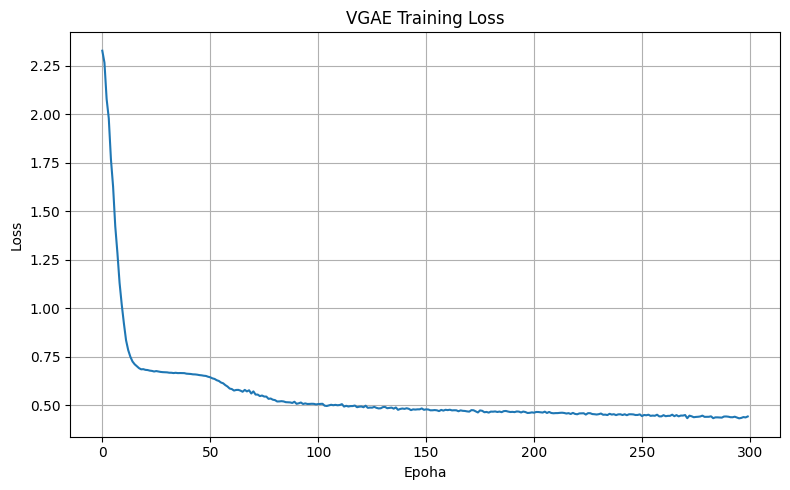

In [7]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.title("VGAE Training Loss")

plt.grid(True)
plt.tight_layout()

plt.savefig("../results/vgae_loss_curve.png", dpi=300)

plt.show()

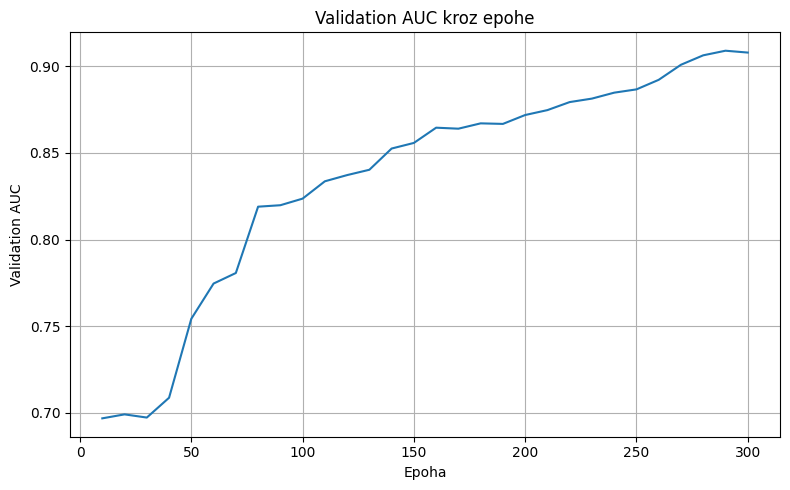

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    range(10, 301, 10),
    val_aucs
)

plt.xlabel("Epoha")
plt.ylabel("Validation AUC")
plt.title("Validation AUC kroz epohe")

plt.grid(True)
plt.tight_layout()

plt.savefig("../results/vgae_auc_curve.png", dpi=300)

plt.show()

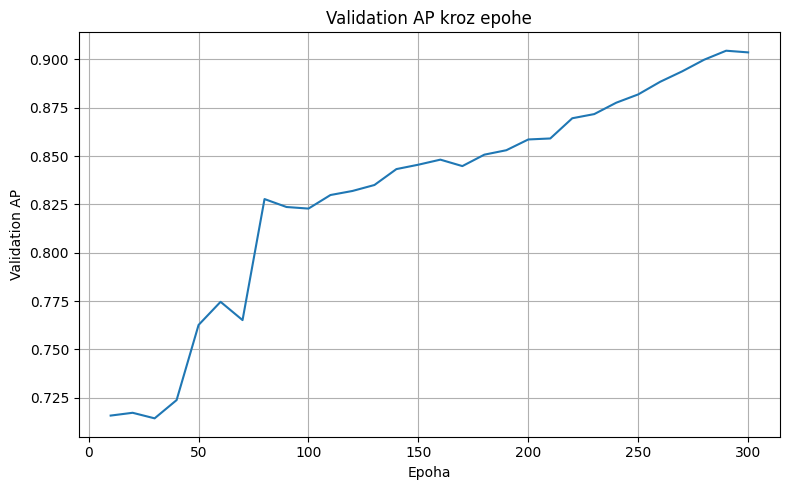

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    range(10, 301, 10),
    val_aps
)

plt.xlabel("Epoha")
plt.ylabel("Validation AP")
plt.title("Validation AP kroz epohe")

plt.grid(True)
plt.tight_layout()

plt.savefig("../results/vgae_ap_curve.png", dpi=300)

plt.show()

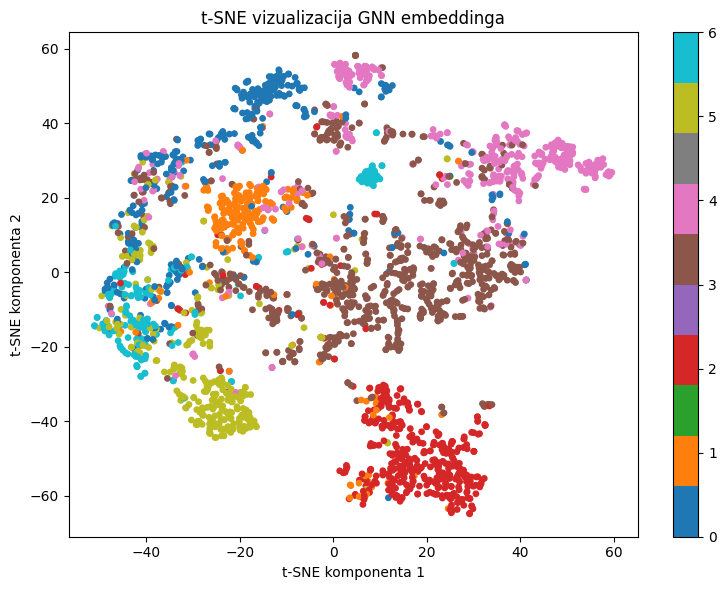

In [10]:

model.eval()

with torch.no_grad():
    z = model.encode(data.x, data.train_pos_edge_index)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

z_2d = tsne.fit_transform(z.cpu().numpy())

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    z_2d[:, 0],
    z_2d[:, 1],
    c=data.y.cpu().numpy(),
    cmap='tab10',
    s=15
)

plt.colorbar(scatter)
plt.title("t-SNE vizualizacija GNN embeddinga")
plt.xlabel("t-SNE komponenta 1")
plt.ylabel("t-SNE komponenta 2")

plt.tight_layout()
plt.savefig('../results/vgae_tSne_embedding.png', dpi=150)
plt.show()

In [11]:
configs = [
    {"hidden": 64,  "out": 32, "lr": 0.01,  "epochs": 200},
    {"hidden": 128, "out": 64, "lr": 0.01,  "epochs": 200},
    {"hidden": 32,  "out": 16, "lr": 0.01,  "epochs": 200},
    {"hidden": 64,  "out": 32, "lr": 0.001, "epochs": 300},
]

results = []

for cfg in configs:

    torch.manual_seed(42)

    model_exp = VGAE(
        in_channels=input_channels,
        hid_channels=cfg["hidden"],
        out_channels=cfg["out"]
    ).to(device)

    optimizer_exp = torch.optim.Adam(model_exp.parameters(), lr=cfg["lr"])

    
    for epoch in range(1, cfg["epochs"] + 1):

        model_exp.train()
        optimizer_exp.zero_grad()
        
        z = model_exp.encode(data.x, data.train_pos_edge_index)

        neg_edge_index = negative_sampling(
            edge_index=all_pos_edge_index,
            num_nodes=data.num_nodes,
            num_neg_samples=data.train_pos_edge_index.shape[1]
        )

        edge_index = torch.cat(
            [data.train_pos_edge_index, neg_edge_index], dim=1
        )

        labels = torch.cat([
            torch.ones(data.train_pos_edge_index.shape[1]),
            torch.zeros(neg_edge_index.shape[1])
        ]).to(device)

        out = model_exp.decode(z, edge_index)

        bce_loss = criterion(out, labels)

        kl_loss = model_exp.kl_loss()

        loss = bce_loss + (1.0 / data.num_nodes) * kl_loss

        loss.backward()
        optimizer_exp.step()

    @torch.no_grad()
    def eval_exp(m, pos_ei, neg_ei):

        m.eval()

        z = m.encode(data.x, data.train_pos_edge_index)

        ei = torch.cat([pos_ei, neg_ei], dim=1)

        out = m.decode(z, ei).sigmoid().cpu().numpy()

        lbl = torch.cat([
            torch.ones(pos_ei.shape[1]),
            torch.zeros(neg_ei.shape[1])
        ]).numpy()

        return (roc_auc_score(lbl, out), average_precision_score(lbl, out))

    test_auc, test_ap = eval_exp(
        model_exp,
        data.test_pos_edge_index,
        test_neg)

    results.append({
        "hidden": cfg["hidden"],
        "out": cfg["out"],
        "lr": cfg["lr"],
        "epochs": cfg["epochs"],
        "Test AUC": round(test_auc, 4),
        "Test AP": round(test_ap, 4)})

    print(f"hidden={cfg['hidden']:3d}, out={cfg['out']:2d}, lr={cfg['lr']} "
          f"→ AUC={test_auc:.4f}, AP={test_ap:.4f}")

hidden= 64, out=32, lr=0.01 → AUC=0.8806, AP=0.8801
hidden=128, out=64, lr=0.01 → AUC=0.8991, AP=0.9013
hidden= 32, out=16, lr=0.01 → AUC=0.8231, AP=0.8292
hidden= 64, out=32, lr=0.001 → AUC=0.6901, AP=0.7103


In [12]:
import pandas as pd

df = pd.DataFrame(results)
df = df.sort_values("Test AUC", ascending=False).reset_index(drop=True)
display(df)

,hidden,out,lr,epochs,Test AUC,Test AP
0,128,64,0.010,200,0.8991,0.9013
1,64,32,0.010,200,0.8806,0.8801
2,32,16,0.010,200,0.8231,0.8292
3,64,32,0.001,300,0.6901,0.7103


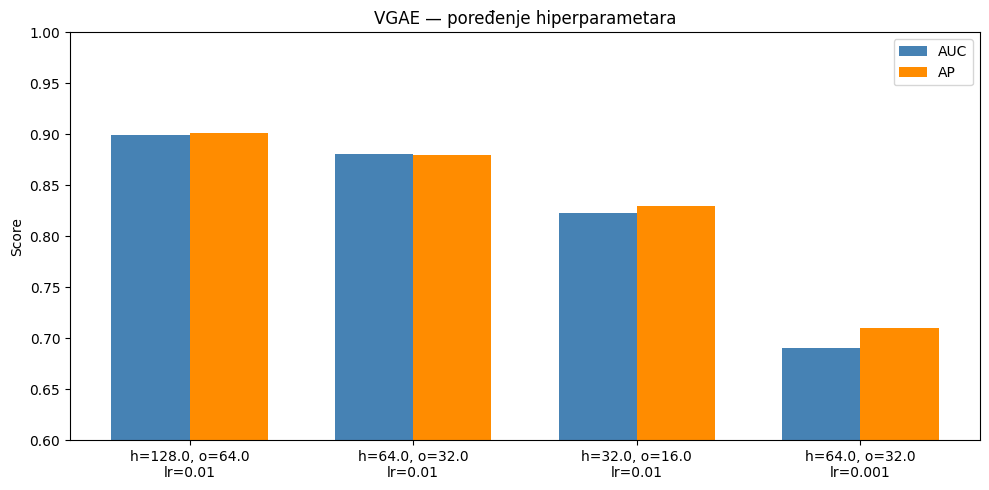

In [13]:
import matplotlib.pyplot as plt

labels_cfg = [f"h={r['hidden']}, o={r['out']}\nlr={r['lr']}" for _, r in df.iterrows()]
auc_vals   = df["Test AUC"].tolist()
ap_vals    = df["Test AP"].tolist()

x = range(len(labels_cfg))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], auc_vals, width, label='AUC', color='steelblue')
ax.bar([i + width/2 for i in x], ap_vals,  width, label='AP',  color='darkorange')

ax.set_ylabel("Score")
ax.set_title("VGAE — poređenje hiperparametara")
ax.set_xticks(list(x))
ax.set_xticklabels(labels_cfg)
ax.set_ylim(0.6, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig('../results/vgae_hyperparams.png', dpi=150)
plt.show()